# Assignment 13 · Notebook 4 — Results & plots

Runs locally (no GPU). Reads the `RESULT_JSON` / `SPEED_SWEEP` lines printed by the three executed Colab notebooks and produces the summary table and the figures used in the README.

run                                       steps   train     val    tok/s  peak GiB  wall min
Baseline (B=32)                            3051   5.251   5.385   35,307      2.37      23.6
Reversible momentum (B=32)                 3051   5.231   5.360   32,195      0.96      25.8
Reversible momentum (B=1408, max)            69   6.920   6.966   24,084     13.12      31.9


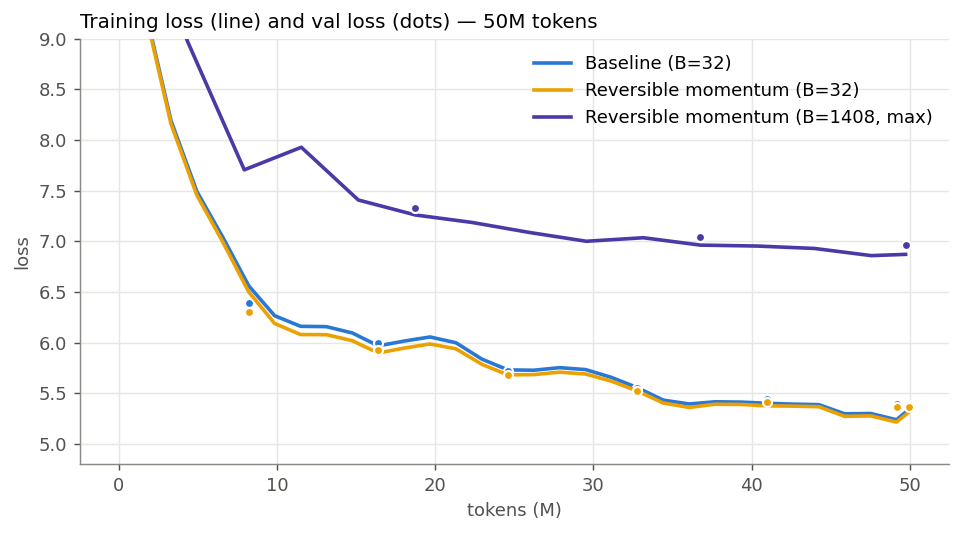

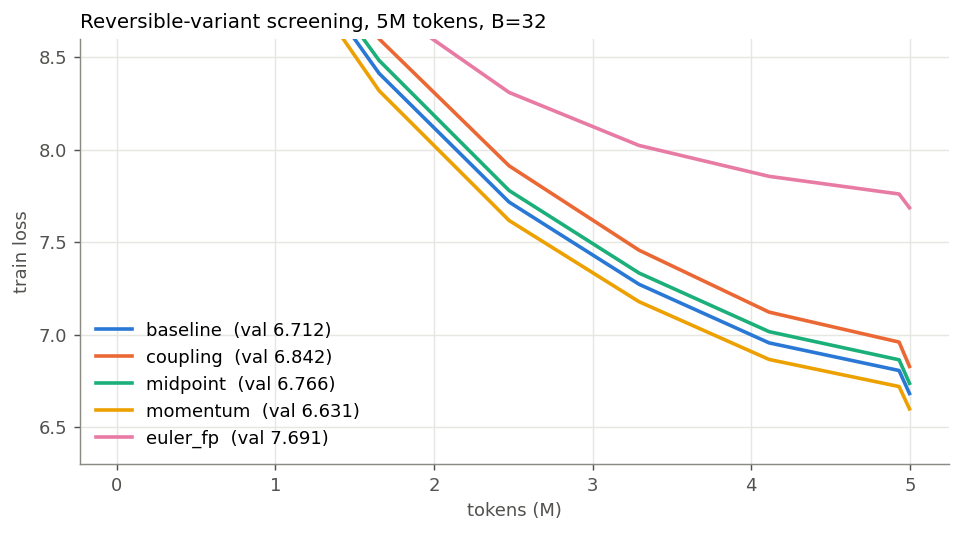

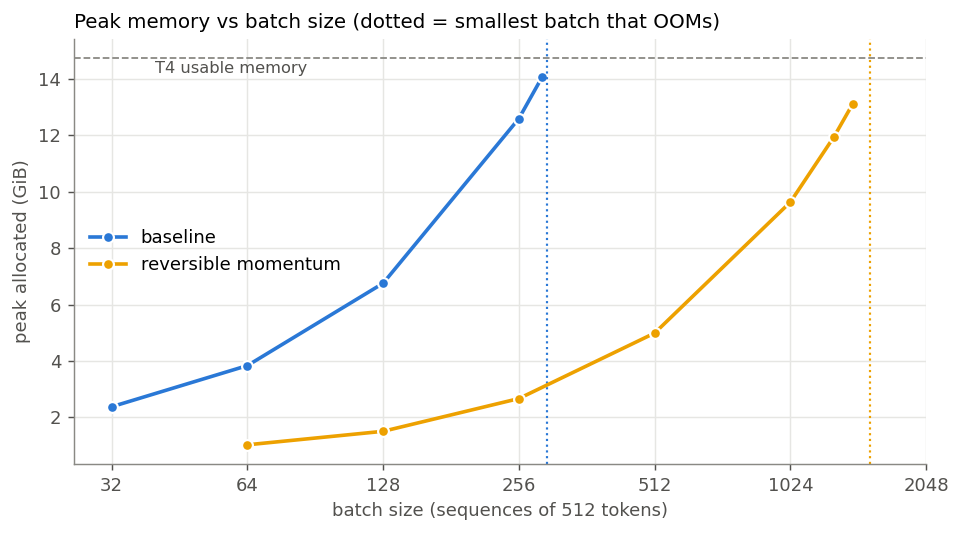

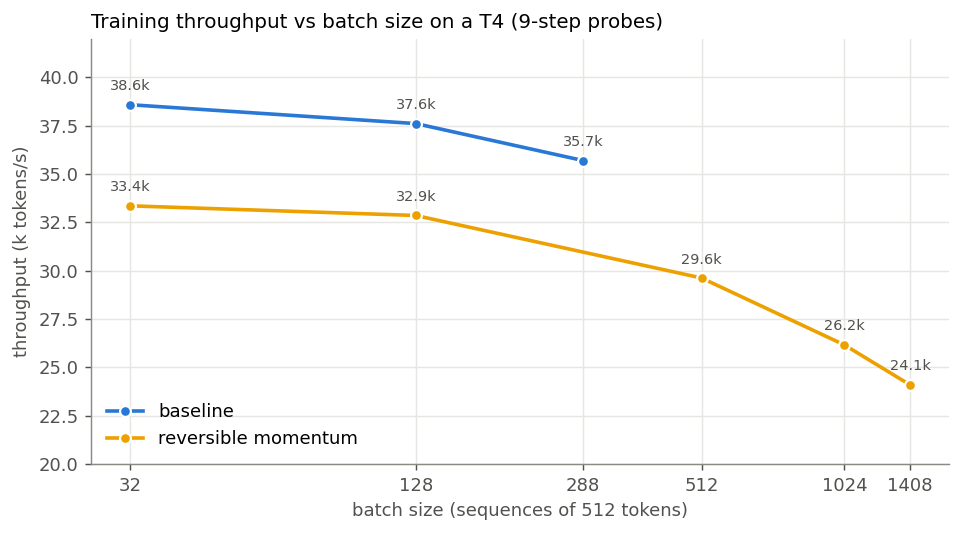

speed sweep (variant, B, tok/s, cumulative cudaMalloc retries): [('baseline', 32, 38592, 6), ('baseline', 128, 37616, 6), ('baseline', 288, 35706, 8), ('momentum', 32, 33362, 8), ('momentum', 128, 32862, 8), ('momentum', 512, 29629, 8), ('momentum', 1024, 26167, 8), ('momentum', 1408, 24101, 10)]


In [1]:
import json, re
import matplotlib.pyplot as plt

def result_json(nb_path):
    nb = json.load(open(nb_path))
    for c in nb["cells"]:
        for o in c.get("outputs", []):
            txt = "".join(o.get("text", "")) if o.get("output_type") == "stream" else ""
            for line in txt.splitlines():
                if line.startswith("RESULT_JSON "):
                    return json.loads(line[len("RESULT_JSON "):])
    raise ValueError(f"no RESULT_JSON in {nb_path}")

base = result_json("01_baseline.ipynb")
rev  = result_json("02_reversible_variants.ipynb")
rmax = result_json("03_reversible_max_batch.ipynb")
full = rev["full"]

# fixed categorical order (colour follows the entity)
COL = {"baseline": "#2a78d6", "coupling": "#eb6834", "midpoint": "#1baf7a",
       "momentum": "#eda100", "euler_fp": "#e87ba4", "rev_max": "#4a3aa7"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8,
                     "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
                     "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "font.size": 10, "lines.linewidth": 2, "figure.dpi": 130})

def smooth(y, k=0.8):
    out, e = [], None
    for v in y:
        e = v if e is None else k * e + (1 - k) * v
        out.append(e)
    return out

# ---- summary table
rows = [("Baseline (B=32)", base), (f"Reversible {rev['best']} (B=32)", full),
        (f"Reversible {rmax['variant']} (B={rmax['B']}, max)", rmax)]
print(f"{'run':40s} {'steps':>6s} {'train':>7s} {'val':>7s} {'tok/s':>8s} {'peak GiB':>9s} {'wall min':>9s}")
for n, r in rows:
    print(f"{n:40s} {r['steps']:6d} {r['final_train_loss_ema']:7.3f} {r['final_val_loss']:7.3f} "
          f"{r['tok_per_s']:8,d} {r['peak_mem_GiB']:9.2f} {r['wall_s']/60:9.1f}")

# ---- 1. loss vs tokens, the three 50M runs
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (n, r), c in zip(rows, [COL["baseline"], COL[rev["best"]], COL["rev_max"]]):
    h = r["hist"]
    y = h["loss"] if r["steps"] < 500 else smooth(h["loss"], 0.6)   # max-batch run: raw (only 69 steps)
    ax.plot([t / 1e6 for t in h["tokens"]], y, color=c, label=n)
    ax.plot([ (s + 1) * r["B"] * r["T"] / 1e6 for s in h["val_step"]], h["val_loss"], "o",
            color=c, ms=5, mec="white", mew=1.2)
ax.set_ylim(4.8, 9); ax.set_xlabel("tokens (M)"); ax.set_ylabel("loss")
ax.set_title("Training loss (line) and val loss (dots) — 50M tokens", loc="left", fontsize=11)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("loss_curves.png"); plt.show()

# ---- 2. screening curves
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for v, r in rev["screen"].items():
    h = r["hist"]
    ax.plot([t / 1e6 for t in h["tokens"]], smooth(h["loss"], 0.6), color=COL[v],
            label=f"{v}  (val {r['final_val_loss']:.3f})")
ax.set_ylim(6.3, 8.6); ax.set_xlabel("tokens (M)"); ax.set_ylabel("train loss")
ax.set_title("Reversible-variant screening, 5M tokens, B=32", loc="left", fontsize=11)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("variant_screening.png"); plt.show()

# ---- 3. memory vs batch size (probe logs)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, log, c in [("baseline", base["max_batch_probe"]["log"], COL["baseline"]),
                     (f"reversible {rmax['variant']}", rmax["max_batch_probe"]["log"], COL[rmax["variant"]])]:
    ok = sorted((b, m) for b, m in log if m)
    oom = sorted(b for b, m in log if not m)
    ax.plot([b for b, _ in ok], [m for _, m in ok], "o-", color=c, ms=6, mec="white", mew=1.2, label=name)
    if oom:
        ax.axvline(min(oom), color=c, ls=":", lw=1.2)
ax.axhline(14.74, color="#8a8984", lw=1, ls="--"); ax.text(40, 14.2, "T4 usable memory", color="#52514e", fontsize=9)
ax.set_xscale("log", base=2); ax.set_xticks([32, 64, 128, 256, 512, 1024, 2048]); ax.set_xticklabels([32, 64, 128, 256, 512, 1024, 2048])
ax.set_xlabel("batch size (sequences of 512 tokens)"); ax.set_ylabel("peak allocated (GiB)")
ax.set_title("Peak memory vs batch size (dotted = smallest batch that OOMs)", loc="left", fontsize=11)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("memory_vs_batch.png"); plt.show()

# ---- 4. throughput vs batch size (diagnostic cell at the end of notebook 3)
import ast
sweep = None
for c in json.load(open("03_reversible_max_batch.ipynb"))["cells"]:
    for o in c.get("outputs", []):
        for line in "".join(o.get("text", "")).splitlines():
            if line.startswith("SPEED_SWEEP "):
                sweep = ast.literal_eval(line[len("SPEED_SWEEP "):])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for v, c, name in [("baseline", COL["baseline"], "baseline"), ("momentum", COL["momentum"], "reversible momentum")]:
    pts = [(B, t) for vv, B, t, _ in sweep if vv == v]
    ax.plot([b for b, _ in pts], [t / 1e3 for _, t in pts], "o-", color=c, ms=6, mec="white", mew=1.2, label=name)
    for b, t in pts:
        ax.annotate(f"{t/1e3:.1f}k", (b, t / 1e3), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=8, color="#52514e")
ax.set_xscale("log", base=2); ax.set_ylim(20, 42)
ax.set_xticks([32, 128, 288, 512, 1024, 1408]); ax.set_xticklabels([32, 128, 288, 512, 1024, 1408])
ax.set_xlabel("batch size (sequences of 512 tokens)"); ax.set_ylabel("throughput (k tokens/s)")
ax.set_title("Training throughput vs batch size on a T4 (9-step probes)", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower left")
fig.tight_layout(); fig.savefig("throughput_vs_batch.png"); plt.show()
print("speed sweep (variant, B, tok/s, cumulative cudaMalloc retries):", sweep)
